In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [5]:
# Setări vizuale
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
# 1. Încărcarea Datelor
try:
    df = pd.read_csv('/content/insurance.csv')
    print(f"✅ Date încărcate! Dimensiuni: {df.shape}")
except FileNotFoundError:
    print("❌ Fișierul nu a fost găsit.")

df.head()

✅ Date încărcate! Dimensiuni: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [46]:
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [7]:
df.tail(5)

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


# 📊 YData Profiling (Overview Automat)

Înainte de a scrie cod pentru fiecare grafic în parte, cel mai eficient pas este să rulăm un raport automat. **YData Profiling** (fostul Pandas Profiling) generează un raport HTML interactiv care ne arată tipurile de date, valorile lipsă (missing values), statistici descriptive și avertismente (ex: coloane cu corelație mare sau cardinalitate ridicată).

In [8]:
!pip install ydata_profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.1 MB/s eta 0:00:00


In [9]:
from ydata_profiling import ProfileReport
# Generarea raportului automat
profile = ProfileReport(df, title="Raport Exploratoriu de Date (EDA)", explorative=True)

# Afisarea raportului direct in Notebook (poate dura cateva secunde)
# Nota: Daca fisierul e prea mare, folositi profile.to_file("raport.html")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 25.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 📈 Analiza Distribuției: Normalitate vs. Asimetrie (KDE)

Aici comparăm două tipuri de distribuții fundamentale în statistică:

**Distribuție Gaussiană (Normală)**: Priviți graficul bmi (Indicele de masă corporală). Are forma unui clopot simetric. Majoritatea oamenilor sunt la mijloc, cu puțini foarte slabi sau foarte obezi.

**Distribuție Skewed (Asimetrică)**: Priviți graficul charges (Costuri medicale). Coada este lungă spre dreapta. Asta înseamnă că majoritatea oamenilor au costuri mici/medii, dar există câțiva cu costuri enorme care trag media în sus.

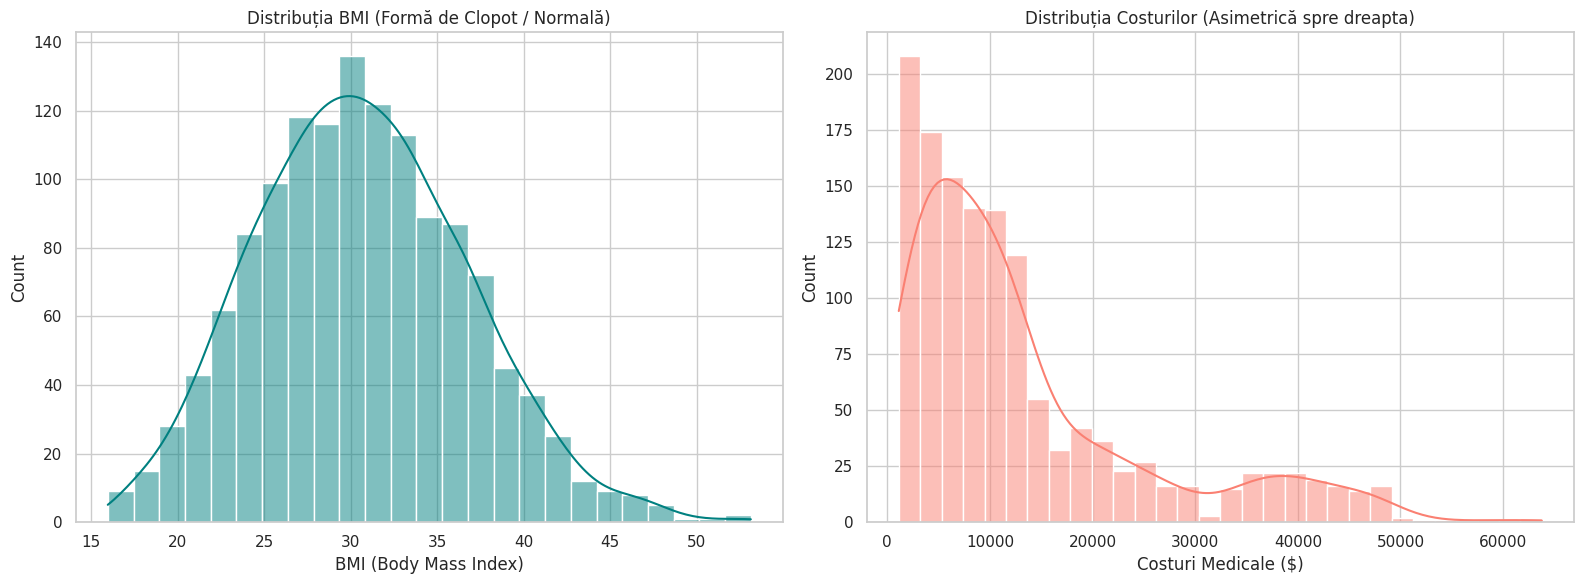

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: BMI - Aproximativ Normală
sns.histplot(df['bmi'], kde=True, color='teal', ax=ax[0])
ax[0].set_title('Distribuția BMI (Formă de Clopot / Normală)')
ax[0].set_xlabel('BMI (Body Mass Index)')

# Plot 2: Charges - Asimetrică (Right Skewed)
sns.histplot(df['charges'], kde=True, color='salmon', ax=ax[1])
ax[1].set_title('Distribuția Costurilor (Asimetrică spre dreapta)')
ax[1].set_xlabel('Costuri Medicale ($)')

plt.tight_layout()
plt.show()

# 📦 Impactul Categoriilor: Boxplot și Violin Plot

Cea mai puternică întrebare în acest dataset: **"Fumatul afectează costurile medicale?"**

**Boxplot-ul (stânga)**: Ne arată clar că mediana (linia din cutie) costurilor pentru fumători (yes) este mult mai sus decât pentru nefumători. Punctele negre la nefumători sunt outlieri (cazuri rare scumpe, probabil boli grave care nu țin de fumat).

**Violin Plot-ul (dreapta)**: Observați forma pentru fumători. Este posibil să vedeți o distribuție "bimodală" (două cocoașe), sugerând că și între fumători există două sub-grupuri de costuri.

/tmp/ipython-input-4167567954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges', ax=ax[0], palette="Set2")
/tmp/ipython-input-4167567954.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='smoker', y='charges', ax=ax[1], palette="Set2", split=True)


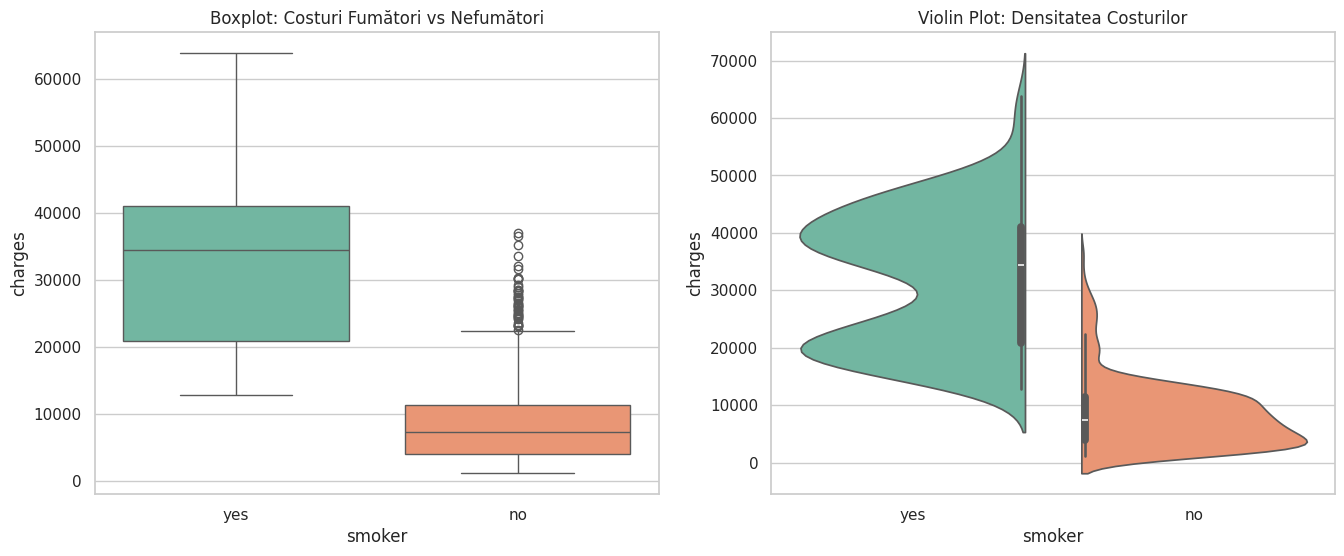

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(data=df, x='smoker', y='charges', ax=ax[0], palette="Set2")
ax[0].set_title('Boxplot: Costuri Fumători vs Nefumători')

# Violin Plot
sns.violinplot(data=df, x='smoker', y='charges', ax=ax[1], palette="Set2", split=True)
ax[1].set_title('Violin Plot: Densitatea Costurilor')

plt.show()

# 🚨 Detectarea Outlierelor pe BMI (Metoda IQR)
Outlierele în bmi reprezintă pacienți cu un indice de masă corporală extrem de mare. Folosim metoda **IQR (Interquartile Range)**:

Calculăm "cutia" (de la 25% la 75% din date).

Orice valoare care depășește cutia cu mai mult de 1.5 ori lungimea ei este considerată outlier.

Vizual: Punctele din dreapta liniei verticale "Limita Superioară" sunt cazurile extreme.

Py

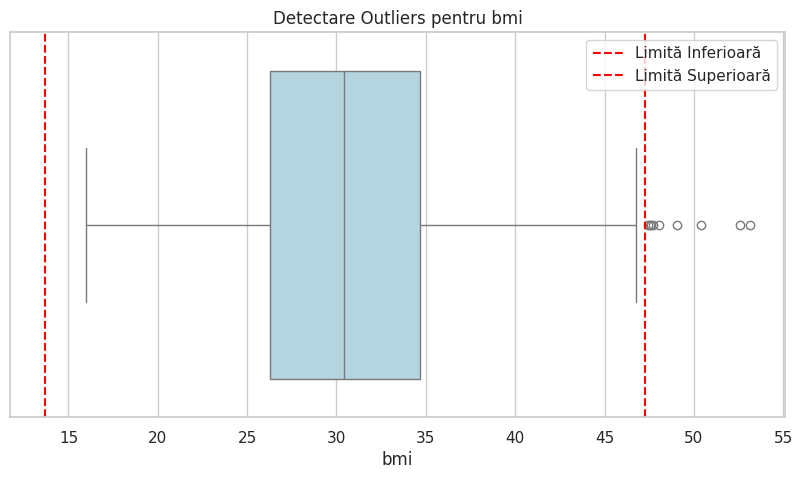

--- Statistici BMI ---
Valori considerate normale între: 13.70 și 47.29
Număr pacienți cu BMI extrem (outliers): 9
Top 5 cele mai mari valori BMI: [53.13 52.58 50.38 49.06 48.07]


In [12]:
def plot_outliers_bmi(df):
    column = 'bmi'

    # Calcul matematic IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Vizualizare
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[column], color='lightblue')

    # Adaugam linii pentru limite
    plt.axvline(x=lower_bound, color='red', linestyle='--', label='Limită Inferioară')
    plt.axvline(x=upper_bound, color='red', linestyle='--', label='Limită Superioară')

    plt.title(f'Detectare Outliers pentru {column}')
    plt.legend()
    plt.show()

    print(f"--- Statistici BMI ---")
    print(f"Valori considerate normale între: {lower_bound:.2f} și {upper_bound:.2f}")
    print(f"Număr pacienți cu BMI extrem (outliers): {len(outliers)}")
    print(f"Top 5 cele mai mari valori BMI: {outliers[column].sort_values(ascending=False).values[:5]}")

plot_outliers_bmi(df)

# 🔗 Matricea de Corelații (Completa)

Pentru a vedea cum se influențează variabilele între ele, trebuie să transformăm textul în numere (sex: male/female $\rightarrow$ 0/1, smoker: yes/no $\rightarrow$ 1/0).

**Pearson**: Vedem o corelație puternică (roșu închis) între smoker_code și charges (~0.78). Asta confirmă matematic ce am văzut vizual: fumatul crește costul. De asemenea, age are o corelație pozitivă cu costurile (pe măsură ce îmbătrânim, plătim mai mult).

**Spearman**: Este mai precaut (robust). Observați dacă relația dintre age și charges devine mai puternică aici (deoarece costurile cresc cu vârsta, dar nu neapărat liniar).

**Phi** (**Corelație binară**): Ne uităm la pătrățelul dintre smoker_code și sex_code. Dacă este aproape de 0, înseamnă că fumatul nu depinde de gen în acest set de date.

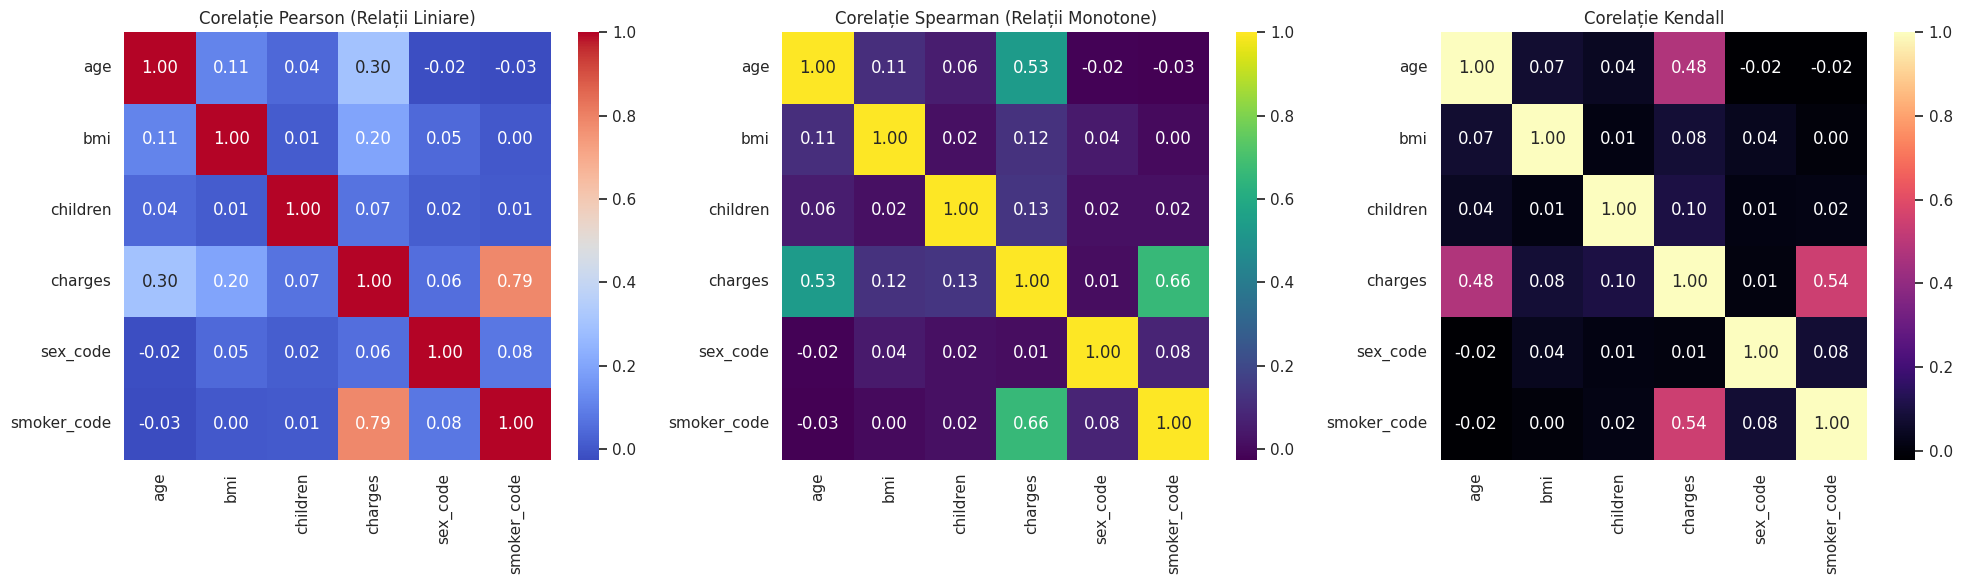

In [13]:
# PREPROCESARE PENTRU CORELATII
# Facem o copie si transformam variabilele categorice in numerice pentru a putea calcula corelatia
df_corr = df.copy()

# Mapare manuală pentru claritate (Label Encoding)
df_corr['sex_code'] = df_corr['sex'].map({'female': 0, 'male': 1})
df_corr['smoker_code'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
# Region este nominală (nu are ordine), deci o excludem din corelațiile simple de rang/liniare
# pastram doar coloanele numerice
cols_for_corr = ['age', 'bmi', 'children', 'charges', 'sex_code', 'smoker_code']

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# 1. Pearson (Liniar)
sns.heatmap(df_corr[cols_for_corr].corr(method='pearson'),
            annot=True, fmt=".2f", cmap='coolwarm', ax=ax[0])
ax[0].set_title('Corelație Pearson (Relații Liniare)')

# 2. Spearman (Ranguri - bun pentru date asimetrice ca 'charges')
sns.heatmap(df_corr[cols_for_corr].corr(method='spearman'),
            annot=True, fmt=".2f", cmap='viridis', ax=ax[1])
ax[1].set_title('Corelație Spearman (Relații Monotone)')

# 3. Kendall (Ordinal - conservator)
sns.heatmap(df_corr[cols_for_corr].corr(method='kendall'),
            annot=True, fmt=".2f", cmap='magma', ax=ax[2])
ax[2].set_title('Corelație Kendall')

plt.tight_layout()
plt.show()

In [13]:
Supervised - etichete (pret)
Unversupervised - nu avem etichete

# Segmentarea pieței

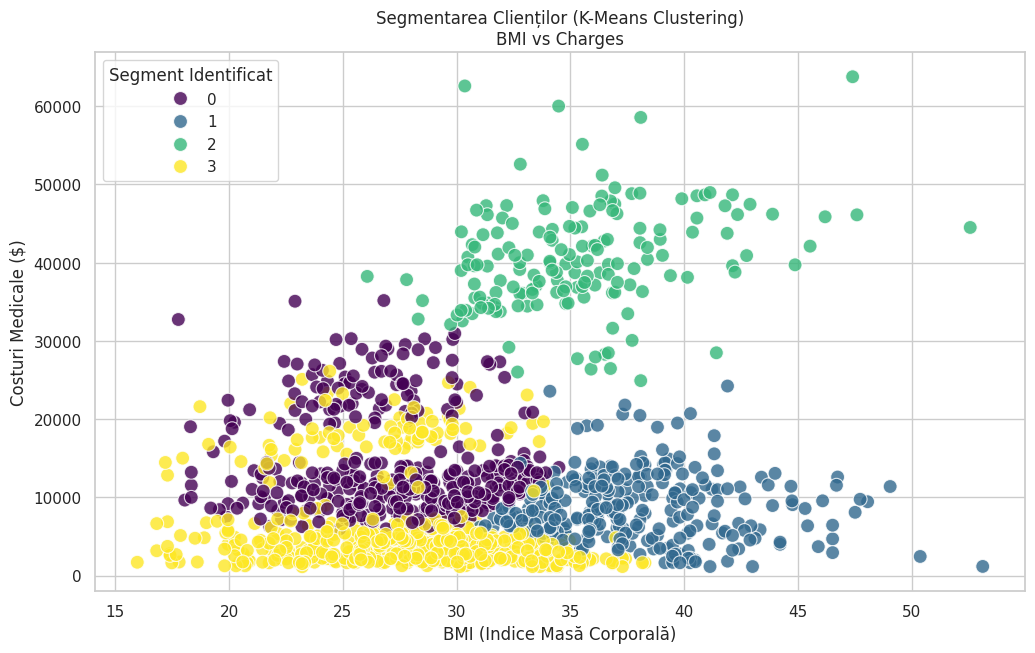

--- Profilul fiecărui Segment (Medii) ---
               age        bmi       charges  smoker_numeric
Cluster                                                    
0        51.521851  27.234666  14099.147282        0.182519
1        43.969388  37.653673   8801.959335        0.000000
2        39.951220  35.371098  40380.541894        0.902439
3        26.350305  27.621792   6234.362083        0.112016


In [14]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Selectăm trăsăturile pe baza cărora vrem să segmentăm
# Vrem să vedem grupuri bazate pe Corp (BMI), Vârstă și Costuri
features = ['age', 'bmi', 'charges']
X = df[features].copy()

# 2. Scalarea datelor (CRITIC pentru K-Means)
# Explicatie: 'charges' are valori de mii, 'age' de zeci. Fără scalare, distanța ar fi dominată doar de bani.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicăm K-Means
# Să zicem că vrem să găsim 4 mari segmente de piață
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# --- VIZUALIZARE ---

# Plot 3D pentru a impresiona (opțional, dar arată bine interactiv)
# Dar pentru claritate 2D, facem un scatterplot colorat după cluster

plt.figure(figsize=(12, 7))

# X=BMI, Y=Charges, Color=Cluster
sns.scatterplot(data=df, x='bmi', y='charges', hue='Cluster', palette='viridis', s=100, alpha=0.8)

plt.title('Segmentarea Clienților (K-Means Clustering)\nBMI vs Charges')
plt.xlabel('BMI (Indice Masă Corporală)')
plt.ylabel('Costuri Medicale ($)')
plt.legend(title='Segment Identificat')

plt.show()


# 1. Transformăm 'smoker' în numere (1=yes, 0=no) în dataframe-ul original
# Astfel putem calcula media (care va reprezenta % de fumători)
df['smoker_numeric'] = df['smoker'].map({'yes': 1, 'no': 0})

# 2. Facem gruparea folosind coloana numerică
# Folosim numeric_only=True pentru siguranță
grupare = df.groupby('Cluster')[['age', 'bmi', 'charges', 'smoker_numeric']].mean(numeric_only=True)

print("--- Profilul fiecărui Segment (Medii) ---")
print(grupare)

# 📉 Determinarea numărului optim de Clustere (Metoda Elbow)

Algoritmul K-Means nu știe singur câte grupuri există. Noi trebuie să îi spunem. Cum alegem între 3, 4 sau 5?Folosim **Metoda "Elbow" (Cotul)**:
1. Rulăm algoritmul pentru $k=1$ până la $k=10$.

2. Calculăm Inerția (suma erorilor): Cât de departe sunt punctele față de centrul grupului lor.

3. Căutăm punctul unde linia face un "cot" brusc. Acolo este echilibrul optim între simplitate și precizie.

Se calculează inerția pentru 1-10 clustere...


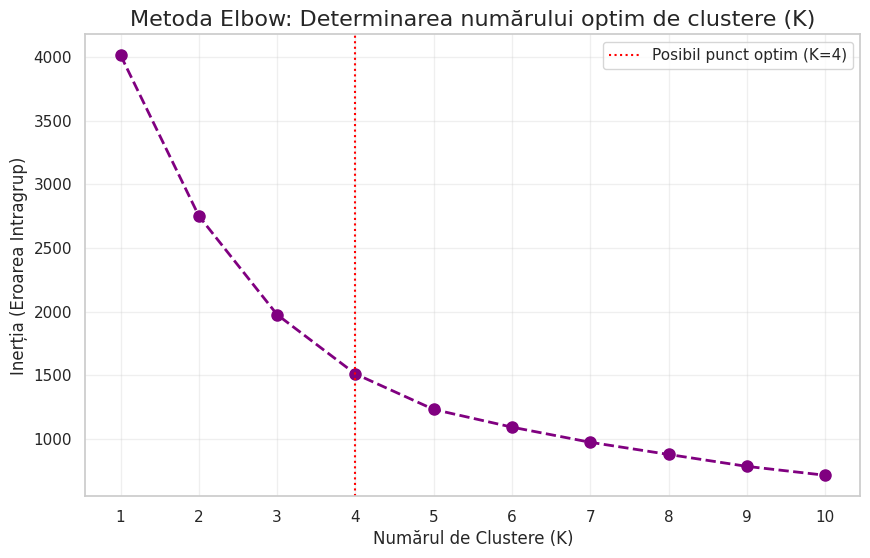

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Pregătirea datelor (La fel ca înainte)
features = ['age', 'bmi', 'charges']
X = df[features].copy()

# Scalarea este OBLIGATORIE pentru Elbow Method
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Calculul Inerției pentru k de la 1 la 10
inertia = []
k_range = range(1, 11)

print("Se calculează inerția pentru 1-10 clustere...")

for k in k_range:
    # Rulăm K-Means temporar
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    # Salvăm valoarea 'inertia_' (suma pătratelor distanțelor)
    inertia.append(kmeans_temp.inertia_)

# 3. Vizualizarea Graficului Elbow
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='purple', linewidth=2, markersize=8)

# Adăugăm detalii vizuale
plt.title('Metoda Elbow: Determinarea numărului optim de clustere (K)', fontsize=16)
plt.xlabel('Numărul de Clustere (K)', fontsize=12)
plt.ylabel('Inerția (Eroarea Intragrup)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, alpha=0.3)

# Evidențiem vizual zona "cotului" (unde panta se schimbă)
# De obicei la acest dataset e pe la 3 sau 4
plt.axvline(x=4, color='red', linestyle=':', label='Posibil punct optim (K=4)')
plt.legend()

plt.show()

# 📝 Cum se citește graficul?
După ce rulează codul de mai sus, va apărea o linie care scade abrupt și apoi se aplatizează.

**Panta abruptă (K=1 la K=3)**: Adăugarea unui nou grup ajută enorm la explicarea datelor. Inerția scade rapid.

**Zona "Cotului" (K=3 sau K=4)**: Aici scăderea începe să încetinească. Acesta este punctul de "randament descrescător".

**Platoul (K > 5)**: Adăugăm grupuri degeaba. Complexitatea crește, dar nu câștigăm multă precizie (supra-segmentare).

**Concluzia**: "Privind graficul, vedem că la 4 curba se îndoaie. Deci, vom alege n_clusters=4 pentru analiza finală."

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from math import pi

# 1. PREPROCESARE: Transformăm categoriile în numere
# Facem o copie ca să nu stricăm datasetul original
df_cluster = df.copy()

# Binary encoding (0/1)
df_cluster['sex'] = df_cluster['sex'].map({'female': 0, 'male': 1})
df_cluster['smoker'] = df_cluster['smoker'].map({'no': 0, 'yes': 1})

# Pentru 'region', folosim One-Hot Encoding (creează coloane separate: region_northwest, etc.)
# dar pentru simplitatea Radar Plot-ului, vom folosi Label Encoding simplu aici sau îl excludem dacă nu e critic.
# Pentru acest exemplu didactic, convertim regiunile în coduri numerice simple pentru a le include,
# deși One-Hot este tehnic mai corect, ar aglomera radar plot-ul cu 4 axe.
df_cluster['region'] = df_cluster['region'].astype('category').cat.codes

# 2. SCALARE PENTRU ALGORITM (StandardScaler)
# K-Means are nevoie de medie 0 și deviație 1 pentru a calcula distanțele corect
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns)

# 3. APLICARE K-MEANS
# Alegem 4 clustere (segmente)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['Cluster'] = kmeans.fit_predict(df_scaled)

# Adăugăm eticheta și în df-ul original pentru interpretare
df['Cluster'] = df_cluster['Cluster']

print("Clustering realizat cu succes! Iată distribuția pe segmente:")
print(df['Cluster'].value_counts())

Clustering realizat cu succes! Iată distribuția pe segmente:
Cluster
1    437
0    340
2    287
3    274
Name: count, dtype: int64


**Crearea Radar Plot-ului (Vizualizarea Profilurilor)**

Aceasta este partea cea mai interesantă. Un Radar Plot ne ajută să vedem "personalitatea" fiecărui grup.

**Nota**: Pentru a desena graficul, calculăm media fiecărei variabile per cluster. Apoi, folosim MinMaxScaler pentru a duce aceste medii în intervalul [0, 1]. Fără acest pas, axa "Charges" (mii) ar face ca "Age" (zeci) să fie invizibilă.

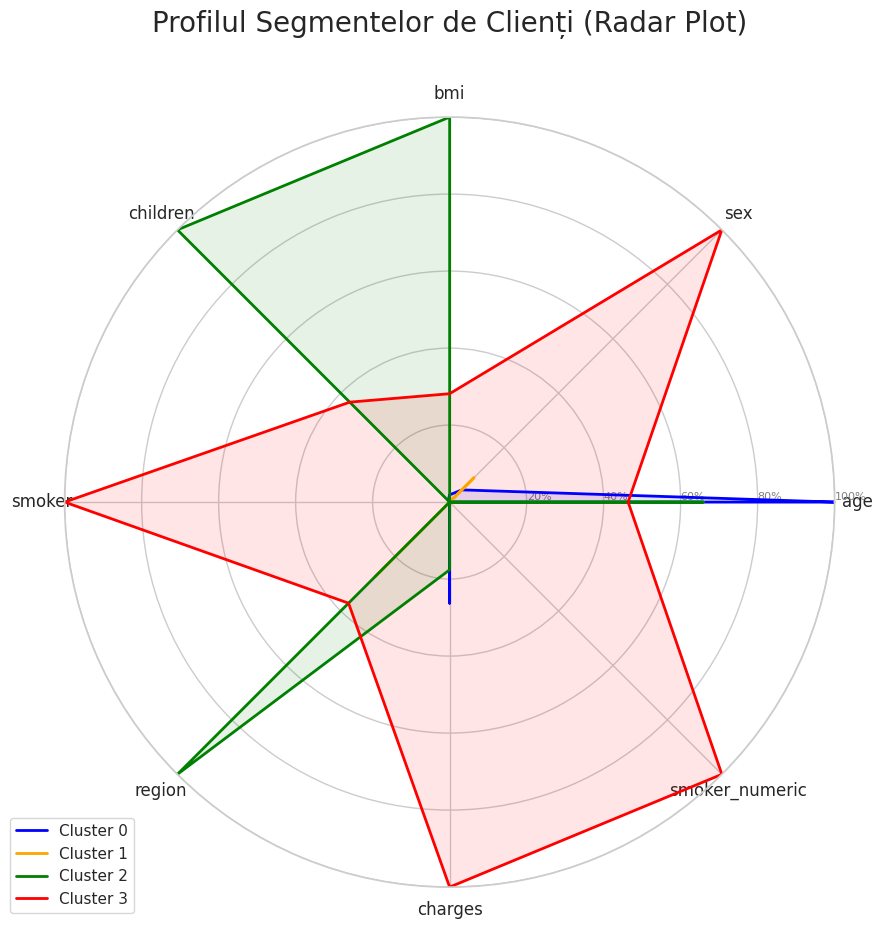

In [17]:
# --- PREGĂTIRE DATE PENTRU RADAR PLOT ---

# 1. Calculăm media fiecărei caracteristici pentru fiecare cluster
cluster_centers = df_cluster.groupby('Cluster').mean()

# 2. Normalizăm valorile între 0 și 1 doar pentru vizualizare (MinMax)
# Astfel putem compara "Salariul" cu "Vârsta" pe același grafic
min_max_scaler = MinMaxScaler()
cluster_centers_scaled = pd.DataFrame(
    min_max_scaler.fit_transform(cluster_centers),
    columns=cluster_centers.columns,
    index=cluster_centers.index
)

# --- FUNCȚIE PENTRU DESENARE RADAR CHART ---
def create_radar_plot(df_centers):
    # Lista de atribute (coloane)
    categories = list(df_centers.columns)
    N = len(categories)

    # Calculăm unghiul pentru fiecare axă
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Închidem cercul (repetăm primul unghi la final)

    # Inițializare plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Desenăm câte o linie pentru fiecare Cluster
    colors = ['blue', 'orange', 'green', 'red']
    labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

    for i, row in df_centers.iterrows():
        values = row.values.flatten().tolist()
        values += values[:1] # Închidem cercul

        ax.plot(angles, values, linewidth=2, linestyle='solid', label=labels[i], color=colors[i])
        ax.fill(angles, values, color=colors[i], alpha=0.1)

    # Setări axe
    plt.xticks(angles[:-1], categories, size=12)

    # Setări etichete Y (cercurile concentrice)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["20%","40%","60%","80%","100%"], color="grey", size=8)
    plt.ylim(0, 1)

    plt.title('Profilul Segmentelor de Clienți (Radar Plot)', size=20, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.show()

create_radar_plot(cluster_centers_scaled)

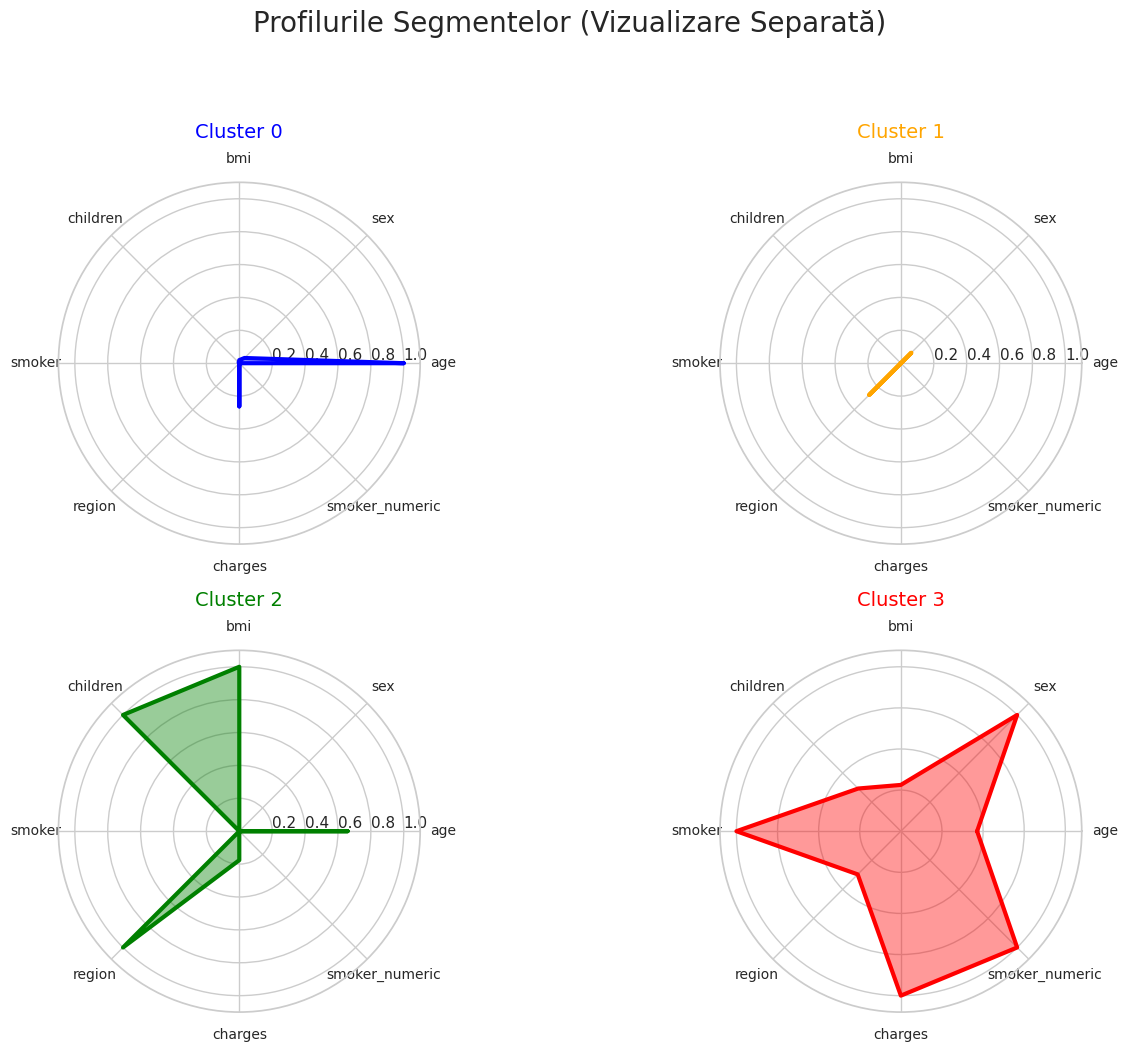

In [18]:
# --- FUNCȚIE PENTRU RADAR PLOT - SMALL MULTIPLES (SEPARATE) ---
def create_radar_plot_separated(df_centers):
    # Configurare inițială
    categories = list(df_centers.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Închidem cercul

    # Setări culori și etichete
    colors = ['blue', 'orange', 'green', 'red']
    labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

    # Creăm o figură cu 4 sub-grafice (2 rânduri x 2 coloane)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw=dict(polar=True))
    # "Aplatizăm" matricea de axe ca să putem itera ușor prin ea
    axes = axes.flatten()

    for i, (ax, color, label) in enumerate(zip(axes, colors, labels)):
        # Extragem valorile pentru clusterul curent 'i'
        values = df_centers.iloc[i].values.flatten().tolist()
        values += values[:1] # Închidem cercul

        # Desenăm linia și umplerea
        ax.plot(angles, values, linewidth=3, linestyle='solid', color=color)
        ax.fill(angles, values, color=color, alpha=0.4) # Alpha mai mare pt claritate

        # Setări axe pentru fiecare sub-grafic
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, size=10)

        # Setări etichete Y (cercurile concentrice) - IMPORTANTE pentru comparație
        ax.set_rlabel_position(0)
        # Punem etichete doar pe primul grafic pentru a nu aglomera
        if i == 0:
             plt.yticks([0.25, 0.5, 0.75, 1.0], ["25%","50%","75%","Max"], color="grey", size=8)
        else:
             plt.yticks([0.25, 0.5, 0.75, 1.0], [])

        # Forțăm aceeași limită maximă pe toate graficele pentru comparație corectă
        ax.set_ylim(0, 1.1)
        ax.set_title(label, size=14, color=color, y=1.1)

    plt.suptitle('Profilurile Segmentelor (Vizualizare Separată)', size=20, y=1.05)
    plt.tight_layout()
    plt.show()

create_radar_plot_separated(cluster_centers_scaled)

Priviți Radar Plot-ul generat. Fiecare culoare este un "Persona" (tip de client). Axele sunt normalizate (100% înseamnă valoarea maximă din acel grup).

**Cum citim aceste grafice?**

**Axe Normalizate**: Nu uitați, valorile de pe axe sunt între 0 (centru) și 1 (margine). "1.0" la age nu înseamnă 1 an, ci înseamnă că acest grup are cea mai mare medie de vârstă dintre toate grupurile.

**Forma Contează**: "Vârfurile" poligonului ne indică caracteristicile dominante ale grupului.

**Analiza "Personalității" Fiecărui Cluster**
Privind cele 4 grafice separate, putem pune etichete clare de business fiecărui segment:


**🔹 Cluster 0 (Albastru): "Seniorii Responsabili"**

Ce vedem: O linie care se duce puternic doar spre dreapta (age).

Caracteristici: Vârstă mare (axa e la 1.0), dar fumatul și costurile sunt moderate.

Concluzie: Sunt pensionarii sau seniorii care au grijă de sănătatea lor.

**🔸 Cluster 1 (Portocaliu): "Tinerii Ideali (Low Risk)"**

Ce vedem: Este acea linie mică, abia vizibilă, concentrată în centrul cercului.

Caracteristici: Valorile sunt minime pe toate axele (aproape de zero).

Concluzie: Tineri, sănătoși, nefumători. Ei sunt cei mai profitabili (costuri minime). Acest grup a făcut schimb de culori cu cel roșu față de exemplul anterior.

**🟢 Cluster 2 (Verde): "Familiile (Dependenți Multipli)"**

Ce vedem: Poligonul care are un "colț" proeminent în stânga-sus (children).

Caracteristici: Număr mare de copii, dar fumat scăzut.

Concluzie: Costurile sunt medii, generate de mărimea familiei, nu de vicii.

**🔴 Cluster 3 (Roșu): "Grupul de Risc Maxim (High Premium)"**

Ce vedem: Este poligonul cel mai mare și extins din grafic.

Caracteristici: Observați că liniile roșii se duc la maxim pe axele smoker, charges (costuri) și bmi.

Concluzie: Aceștia sunt clienții care costă cel mai mult compania (fumători, cu greutate mare). Nu este riscul minim, ci riscul maxim!

Notă: Culorile pot varia la fiecare rulare dacă nu este setat random_state. Identificați grupul după formă, nu doar după culoare!

**Concluzie de Business**: Prin K-Means și Radar Plots, am trecut de la o bază de date cu mii de linii la 4 profiluri clare de clienți. O companie de asigurări ar folosi aceste informații pentru a crea pachete personalizate sau pentru a ajusta calculul riscului pentru fiecare tipologie identificată.

**De ce Radar Plot?** Pentru că ne permite să vedem multi-dimensionalitatea unui grup dintr-o singură privire. Un simplu grafic de bare nu ne-ar fi arătat combinația simultană de "Fumător + Obez + Costisitor".

# 🎓 Lecție Interactivă: Cum funcționează K-Means?
K-Means este un algoritm de **Învățare Nesupervizată**. Asta înseamnă că nu avem răspunsurile corecte (etichete). Îi dăm datele și îi spunem: "*Găsește-mi 3 grupuri care seamănă între ele*".

Algoritmul funcționează în 3 pași repetitivi:

**Inițializare**: Alege la întâmplare 3 puncte (dacă vrem 3 grupuri) și le numește Centroizi.

**Asignare**: Fiecare punct de date își alege centroidul cel mai apropiat.

**Actualizare**: Centroidul se mută în media (centrul geometric) al punctelor care l-au ales. Procesul se repetă până când centroizii nu se mai mișcă.

**👇 Rulați codul de mai jos pentru a vedea acest proces "live"**:

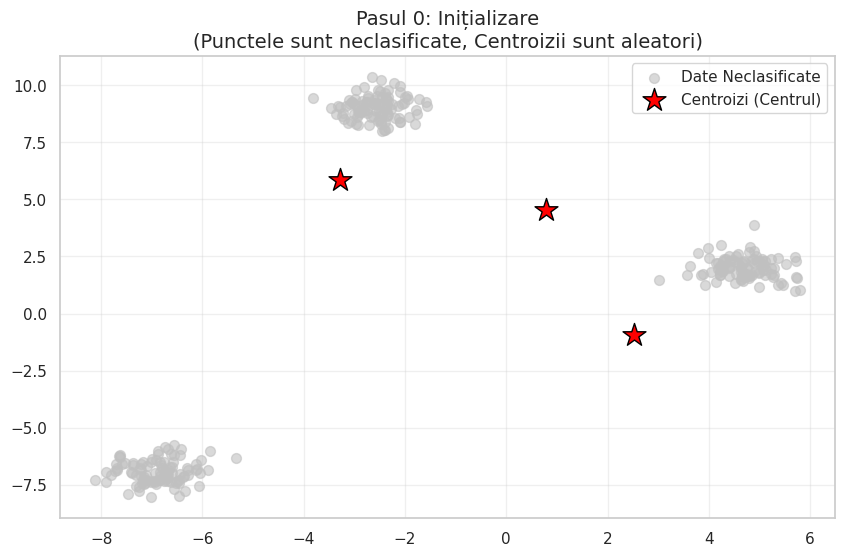

Output()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. GENERARE DATE SIMPLIFICATE ---
# cluster_std=0.5 face grupurile mai clare, deci algoritmul termină mai repede (4-6 pași)
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.50, random_state=42)

class KMeansSimulator:
    def __init__(self, data, k=3):
        self.X = data
        self.k = k
        self.iteration = 0
        self.centroids = None
        self.labels = None
        self.finished = False

        # Output widget pentru grafic
        self.out = widgets.Output()

        # Start random
        self.initialize_random()
        self.plot_state()

    def initialize_random(self):
        # Alegem 3 puncte random din spațiul datelor
        min_val = np.min(self.X, axis=0)
        max_val = np.max(self.X, axis=0)
        self.centroids = np.random.uniform(min_val, max_val, size=(self.k, 2))
        self.labels = None # La pasul 0 nu avem etichete (totul e gri)
        self.finished = False
        self.iteration = 0

    def assign_clusters(self):
        # Calculăm distanțele
        distances = np.linalg.norm(self.X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def step(self, b):
        if self.finished:
            return

        with self.out:
            # 1. Asignare (Colorăm punctele pe baza centroizilor actuali)
            new_labels = self.assign_clusters()

            # Verificăm dacă algoritmul s-a oprit (etichetele nu se mai schimbă)
            if self.labels is not None and np.array_equal(new_labels, self.labels):
                self.finished = True
                self.plot_state(title_suffix=" - CONVERGENȚĂ ATINSĂ! ✅")
                return

            self.labels = new_labels

            # 2. Actualizare (Mutăm centroizii în media punctelor)
            new_centroids = []
            for i in range(self.k):
                points = self.X[self.labels == i]
                if len(points) > 0:
                    new_centroids.append(points.mean(axis=0))
                else:
                    new_centroids.append(self.centroids[i])
            self.centroids = np.array(new_centroids)

            self.iteration += 1
            self.plot_state()

    def reset(self, b):
        with self.out:
            plt.close('all') # Curățăm memoria
            self.initialize_random()
            self.plot_state()

    def plot_state(self, title_suffix=""):
        clear_output(wait=True) # Șterge frame-ul anterior
        plt.close('all') # Siguranță extra

        fig, ax = plt.subplots(figsize=(10, 6))

        # LOGICA DE CULOARE:
        # Pasul 0 -> Toate punctele sunt gri (silver)
        # Pasul 1+ -> Punctele sunt colorate după cluster
        if self.iteration == 0:
            ax.scatter(self.X[:, 0], self.X[:, 1], c='silver', s=50, alpha=0.6, label='Date Neclasificate')
            title = "Pasul 0: Inițializare\n(Punctele sunt neclasificate, Centroizii sunt aleatori)"
        else:
            ax.scatter(self.X[:, 0], self.X[:, 1], c=self.labels, s=50, cmap='viridis', alpha=0.6)
            title = f"Pasul {self.iteration}: Actualizare{title_suffix}"

        # Desenăm Centroizii
        ax.scatter(self.centroids[:, 0], self.centroids[:, 1], c='red', s=300, marker='*', edgecolors='black', label='Centroizi (Centrul)')

        ax.set_title(title, fontsize=14)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

# --- INTERFAȚA ---
sim = KMeansSimulator(X, k=3)

btn_next = widgets.Button(description="Pasul Următor ➡️", button_style='success')
btn_reset = widgets.Button(description="Resetare 🔄", button_style='warning')

btn_next.on_click(sim.step)
btn_reset.on_click(sim.reset)

display(widgets.HBox([btn_next, btn_reset]))
display(sim.out)

**Pasul 0 (Start)**: Punctele sunt gri. Algoritmul "nu vede" încă structura. Vedeți doar 3 stele roșii aruncate la întâmplare.

**Click 1**: Brusc, punctele capătă culoare! Fiecare punct alege steaua cea mai apropiată, iar steaua se mută imediat în "mijlocul" noilor săi prieteni.

**Click 2-5**: Stelele își ajustează poziția fin. Punctele de la graniță își pot schimba culoarea (tabăra).

**Final**: Când apăsați și nu se mai întâmplă nimic (apare mesajul "Convergență"), algoritmul a terminat. Datorită datelor curate, ar trebui să dureze maxim 5-6 click-uri.

# EDA are două niveluri:

**EDA Univariat/Bivariat (Clasic)**: Când ne uităm la histograme sau corelații simple (ex: "Fumatul crește costul?").

**EDA Multivariat (Clustering)**: Când vrem să găsim modele ascunse care implică toate coloanele simultan (ex: "Există un grup de tineri, care nu fumează, dar au BMI mare și locuiesc în sud-vest?").

<Figure size 1500x1000 with 0 Axes>

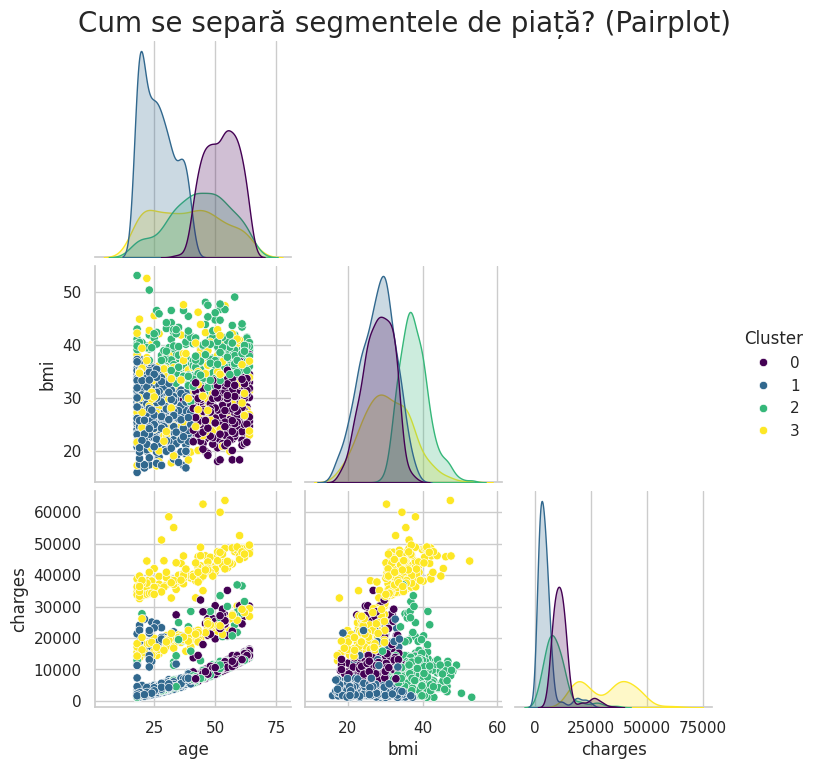

In [20]:
# --- CLUSTERING CA INSTRUMENT DE EDA ---

# Folosim coloana 'Cluster' pe care am creat-o anterior cu K-Means
# Dacă nu o mai ai, rulează din nou codul de K-Means de mai sus

# Selectăm doar câteva coloane relevante pentru a nu aglomera graficul
cols_to_plot = ['age', 'bmi', 'charges', 'Cluster']

# Vizualizăm relațiile dintre variabile, colorate pe grupurile găsite de AI
plt.figure(figsize=(15, 10))
sns.pairplot(df[cols_to_plot], hue='Cluster', palette='viridis', corner=True)
plt.suptitle("Cum se separă segmentele de piață? (Pairplot)", y=1.02, fontsize=20)
plt.show()

# Validarea Matematică: Pairplot-ul
(Pairplot Colorat): Acesta este momentul de "convingere". Aici studenții văd că profilurile de mai sus nu sunt inventate, ci există fizic în distribuția datelor.

**1. Focus pe graficul age vs charges (Stânga Jos):**

Ce vedem: Trei benzi distincte de puncte care urcă odată cu vârsta. Algoritmul le-a colorat diferit, separându-le logic.

**Banda de SUS (Galben - Cluster 3)**: Aceștia sunt clienții "High Risk". Indiferent de vârstă (chiar și la 20 de ani), ei plătesc enorm (sar direct la 30.000$ - 50.000$).

**Banda din MIJLOC (Verde - Cluster 2)**: Sunt familiile sau cazurile cu complicații medii. Costurile sunt moderate.

**Banda de JOS (Mov și Albastru - Clusterele 0 și 1)**: Aici sunt "Seniorii Responsabili" și "Tinerii Ideali". Observați că banda rămâne jos chiar și la 60 de ani (costuri sub 15.000$). Aceasta este zona de profit maxim sigur.

**2. Focus pe graficul bmi vs charges (Mijloc Jos):**

**Ce vedem**: O separare clară bazată pe greutate.

**Insight Vizual**: Uitați-vă la punctele Galbene (Cluster 3). Observați că ele apar aproape exclusiv în partea dreaptă, unde BMI este peste 30?

**Concluzie**: Acest lucru validează vizual regula de business: Obezitate (BMI > 30) + Fumat = Explozie de costuri. Punctele mov și verzi (nefumătorii) rămân jos, chiar dacă au BMI mare.

💡 Concluzie de Business: Ceea ce ați realizat se numește Customer Segmentation. O companie de asigurări folosește exact aceste modele pentru a nu pierde bani:

Identifică automat clienții Galbeni și le crește prima de asigurare.

Oferă reduceri clienților Mov/Albaștri pentru a-i atrage, știind că sunt profitabili.

**1. De ce in pair plot avem pe diagonale grafice fara explicatii sau axe? (Problema "Oglinzii")**

Într-un pairplot, fiecare pătrățel intersectează variabila de pe rând (Y) cu variabila de pe coloană (X).

**În afara diagonalei**: Avem Age vs Charges. Vedem o relație între două lucruri diferite (Scatterplot).

Pe diagonală: Avem Age vs Age.

Dacă am face un scatterplot, am obține o linie dreaptă perfectă (pentru că 20 ani = 20 ani). Asta nu ne-ar oferi nicio informație utilă.

De aceea, biblioteca Seaborn este inteligentă și **înlocuiește linia inutilă cu Distribuția Variabilei**.

**2. Ce reprezintă "Munții" sau "Barele"?**
Ceea ce vezi pe diagonală este **Analiză Univariată** (o singură variabilă).

**Dacă vezi "Munți" (linii curbe)**: Aceasta este o **KDE (Kernel Density Estimation)**. Îți arată probabilitatea.

Un "vârf" înalt înseamnă că multe date sunt concentrate acolo.

O zonă plată înseamnă că datele sunt rare.

**Dacă vezi "Bare"**: Este o **Histogramă** clasică.

**3. De ce nu au axe explicite pe Y?**
Graficele de pe diagonală împart axa X cu restul coloanei (deci valorile de jos, 20, 40, 60, sunt valabile și pentru ele).

Axa Y (înălțimea) lipsește intenționat sau nu are etichete pentru a nu aglomera graficul ("chart junk").

Nu ne interesează neapărat valoarea numerică exactă a densității (ex: 0.003).

Ne interesează **FORMA**:

"Aha, distribuția galbenă (Tinerii) este un turn ascuțit la stânga (vârste mici)."

"Distribuția mov (Seniorii) este o 'cocoașă' mai la dreapta."

**Rezumat:**
"Pe diagonală, graficul nu ne arată relația dintre două variabile, ci **radiografia** acelei singure variabile. Ne arată unde sunt concentrați cei mai mulți oameni din fiecare cluster."

**Separarea Clară:**

Dacă te uiți la graficul charges vs age (de obicei în colțul stânga-jos sau mijloc), vei vedea că cele 3-4 culori (clusterele) formează benzi distincte.

Asta validează faptul că "**Segmentarea a funcționat**". Datele nu sunt amestecate, ci sunt structurate logic.

**Identificarea Outlierelor**:

Dacă vezi un punct "mov" (să zicem Cluster 0) rătăcit în mijlocul unei mări de puncte "galbene" (Cluster 1), acela este un caz atipic care merită investigat.

**Feature Engineering (Ingineria Trăsăturilor)**:

Explicație de aur pentru studenți: "În EDA, folosim clustering nu doar să ne uităm la poze, ci să creăm date noi. Coloana 'Cluster' devine o informație nouă (Feature) pe care o putem da mai departe unui model de predicție (Regresie) pentru a ghici prețul mai exact!"

**Pe scurt**: În EDA, Clustering-ul este ca și cum ai aprinde lumina într-o cameră întunecată. Înainte vedeai doar contururi (media, mediana), acum vezi obiectele distincte (grupurile de clienți).

# 🧠 Lecția 1: Preprocesarea Datelor Categorice

În Machine Learning, nu toate datele text sunt la fel. Avem două tipuri principale de transformări:

## 1. Label Encoding (Codificare prin Etichete)
Atribuie un număr fiecărei categorii (0, 1, 2...).

**Când se folosește?**

Pentru date **binare** (doar două opțiuni: da/nu, femeie/bărbat).

Pentru date **ordinale** (unde există o ordine clară: mic < mediu < mare).

**Exemplu**: smoker: 'yes' -> 1, 'no' -> 0.

## 2. One-Hot Encoding (Codificare "Unul-Cald")
Creează o coloană nouă pentru fiecare categorie posibilă, marcând cu 1 prezența categoriei și 0 absența.

**Când se folosește?**

Pentru date **nominale** (fără ordine intrinsecă) cu mai mult de 2 categorii.

**De ce?** Dacă am codifica region ca 0 (Sud), 1 (Nord), 2 (Est), algoritmul ar putea crede matematic că Est > Sud (2 > 0), ceea ce este fals. Regiunile sunt doar diferite, nu "mai mari". One-Hot evită această confuzie.

In [21]:
data = df.copy()

In [22]:
df

,age,sex,bmi,children,smoker,region,charges,Cluster,smoker_numeric
0,19,female,27.900,0,yes,southwest,16884.92400,3,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0
1334,18,female,31.920,0,no,northeast,2205.98080,1,0
1335,18,female,36.850,0,no,southeast,1629.83350,1,0
1336,21,female,25.800,0,no,southwest,2007.94500,1,0


In [23]:
cols_to_drop = ['Cluster', 'smoker_numeric']

# Verificăm dacă există înainte să le ștergem (ca să nu primim eroare dacă rulăm celula de 2 ori)
data = data.drop(columns=[col for col in cols_to_drop if col in data.columns])

In [24]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [25]:
# --- APLICARE ---

# Copiem datele pentru a nu strica originalul
df_clean = data.copy()

# A. Label Encoding pentru variabile BINARE
# Aici ordinea nu contează (0 vs 1 e doar o comutare) sau există o ordine implicită
mappings = {'yes': 1, 'no': 0, 'female': 1, 'male': 0}

df_clean['smoker'] = df_clean['smoker'].map(mappings)
df_clean['sex'] = df_clean['sex'].map(mappings)

print("După Label Encoding (sex, smoker):")
display(df_clean[['sex', 'smoker']].head(3))

# B. One-Hot Encoding pentru variabile NOMINALE (Region)
# 'region' are 4 valori. Vom crea coloane separate pentru ele.
# drop_first=True este crucial pentru a evita "Dummy Variable Trap" (coliniaritate perfectă)
df_clean = pd.get_dummies(df_clean, columns=['region'], drop_first=True)

# Convertim coloanele booleene (True/False) generate de get_dummies în int (1/0)
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

print("\nDupă One-Hot Encoding (region):")
display(df_clean.head(3))

După Label Encoding (sex, smoker):


,sex,smoker
0,1,1
1,0,0
2,0,0



După One-Hot Encoding (region):


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.90,0,1,16884.9240,0,0,1
1,18,0,33.77,1,0,1725.5523,0,1,0
2,28,0,33.00,3,0,4449.4620,0,1,0


In [26]:
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [27]:
df_clean

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,1
1,18,0,33.770,1,0,1725.55230,0,1,0
2,28,0,33.000,3,0,4449.46200,0,1,0
3,33,0,22.705,0,0,21984.47061,1,0,0
4,32,0,28.880,0,0,3866.85520,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0
1334,18,1,31.920,0,0,2205.98080,0,0,0
1335,18,1,36.850,0,0,1629.83350,0,1,0
1336,21,1,25.800,0,0,2007.94500,0,0,1


# 📊 Lecția 2: Pregătirea și Împărțirea Datelor
Înainte de a antrena modelele, trebuie să standardizăm datele. Algoritmul Gradient Descent (scris de noi) este foarte sensibil la scara datelor (diferența dintre vârsta de 20 de ani și costul de 10.000$). sklearn se descurcă mai bine, dar standardizarea este "best practice".

In [28]:
# 1. Separăm Features (X) și Target (y)
X = df_clean.drop('charges', axis=1).values
y = df_clean['charges'].values

# 2. Împărțim în Train (80%) și Validation/Test (20%)
# Folosim funcția din sklearn pentru rapiditate și consistență
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardizare (Z-Score Normalization)
# x_nou = (x - mean) / std
scaler = StandardScaler()

# "Fit" doar pe train pentru a afla media/std, apoi "Transform" pe ambele
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Dimensiuni Train: {X_train_scaled.shape}")
print(f"Dimensiuni Val: {X_val_scaled.shape}")

Dimensiuni Train: (1070, 8)
Dimensiuni Val: (268, 8)


# 🛠️ Sectiunea A: Regresie Liniară "From Scratch"

Aici implementăm matematica din spatele modelului.Vom folosi **Gradient Descent**.

Formula ipotezei: $h_\theta(x) = X \cdot \theta$

Formula de update: $\theta = \theta - \alpha \cdot \frac{1}{m} X^T (X \cdot \theta - y)$

In [29]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        # 1. Adăugăm coloana de Bias (1) la matricea X
        m = len(y)
        ones = np.ones((m, 1))
        X_b = np.concatenate((ones, X), axis=1)

        # 2. Inițializăm greutățile (theta) cu zero
        self.theta = np.zeros(X_b.shape[1])

        # 3. Gradient Descent
        for i in range(self.iterations):
            # Predicție
            predictions = X_b.dot(self.theta)
            errors = predictions - y

            # Calcul Gradient
            gradient = (1/m) * X_b.T.dot(errors)

            # Update Theta
            self.theta = self.theta - self.lr * gradient

            # Calcul Cost (pentru grafic)
            cost = (1/(2*m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        m = len(X)
        ones = np.ones((m, 1))
        X_b = np.concatenate((ones, X), axis=1)
        return X_b.dot(self.theta)

In [30]:
# --- Antrenare Model Scratch ---
model_scratch = LinearRegressionFromScratch(learning_rate=0.1, iterations=500)
model_scratch.fit(X_train_scaled, y_train)

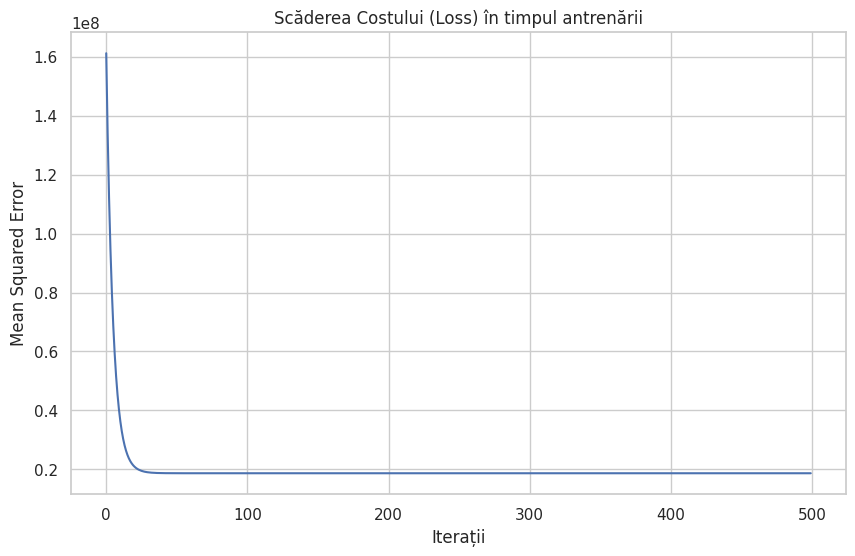

In [31]:
# Plot Loss
plt.plot(model_scratch.cost_history)
plt.title('Scăderea Costului (Loss) în timpul antrenării')
plt.xlabel('Iterații')
plt.ylabel('Mean Squared Error')
plt.show()

# 🤖 Sectiunea B: Regresie Liniară cu Scikit-Learn
În industrie, rareori scriem Gradient Descent de mână. Folosim sklearn deoarece:

1.   Este optimizat în C++ (foarte rapid).
2.   Folosește rezolvitori matematici avansați (SVD, OLS) care găsesc soluția exactă instantaneu, fără a fi nevoie de "iterații" sau Learning Rate manual.





In [32]:
# --- Antrenare Model Sklearn ---

# Instanțiem modelul
sklearn_model = LinearRegression()

In [33]:
# Antrenăm (metoda .fit)
sklearn_model.fit(X_train_scaled, y_train)

LinearRegression()

In [34]:
# Observăm că nu avem nevoie de learning rate sau iterații!
print("Modelul Sklearn a fost antrenat!")
print(f"Bias (Intercept): {sklearn_model.intercept_:.2f}")
print(f"Coeficienți (Weights): {sklearn_model.coef_}")

Modelul Sklearn a fost antrenat!
Bias (Intercept): 13346.09
Coeficienți (Weights): [ 3.61497541e+03  9.29310107e+00  2.03622812e+03  5.16890247e+02
  9.55848141e+03 -1.58140981e+02 -2.90157047e+02 -3.49110678e+02]


# 🏆 Comparație și Concluzii

Haideți să vedem care model a performat mai bine calculând scorul $R^2$ pe setul de validare.

In [35]:
# Predicții Scratch
y_pred_scratch = model_scratch.predict(X_val_scaled)
score_scratch = r2_score(y_val, y_pred_scratch)

# Predicții Sklearn
y_pred_sklearn = sklearn_model.predict(X_val_scaled)
score_sklearn = r2_score(y_val, y_pred_sklearn)

print(f"📊 Rezultate Finale (R-Squared):")
print(f"--------------------------------")
print(f"Model 'From Scratch': {score_scratch:.5f}")
print(f"Model 'Scikit-Learn': {score_sklearn:.5f}")

# Diferența
diff = abs(score_scratch - score_sklearn)
if diff < 0.01:
    print("\n✅ Felicitări! Modelul tău manual este la fel de bun ca cel profesional!")
else:
    print("\n⚠️ Mai trebuie ajustat Learning Rate-ul sau numărul de iterații.")

📊 Rezultate Finale (R-Squared):
--------------------------------
Model 'From Scratch': 0.78359
Model 'Scikit-Learn': 0.78359

✅ Felicitări! Modelul tău manual este la fel de bun ca cel profesional!


# Feature Importance

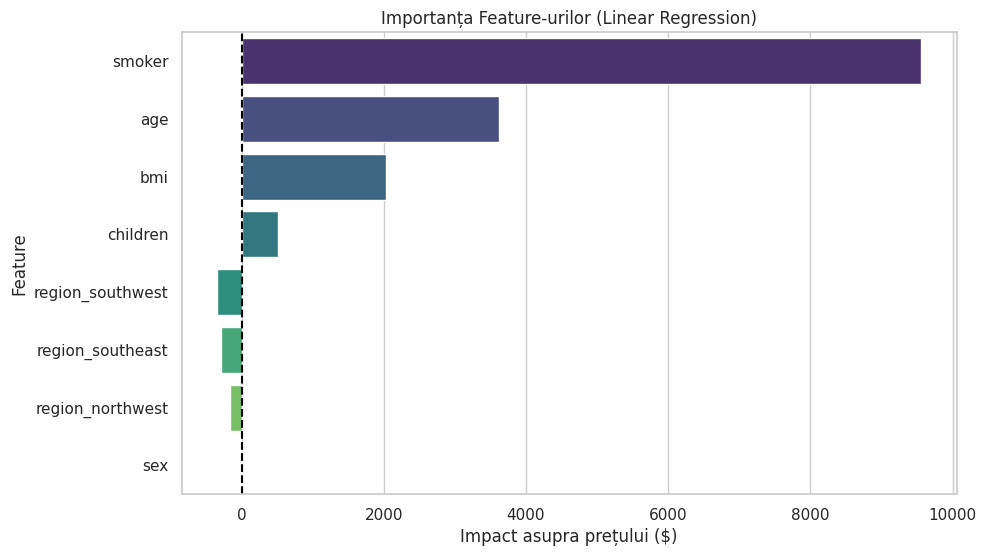

Interpretare: Observați cum 'smoker' domină complet graficul!


In [36]:
# Extragem coeficienții
feature_names = df_clean.drop('charges', axis=1).columns
coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': sklearn_model.coef_
})

# Sortăm după valoarea absolută (magnitudine)
coefs['Abs_Coefficient'] = coefs['Coefficient'].abs()
coefs = coefs.sort_values(by='Abs_Coefficient', ascending=False)

# Vizualizare
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefs, hue='Feature', palette='viridis', legend=False)
plt.title('Importanța Feature-urilor (Linear Regression)')
plt.xlabel('Impact asupra prețului ($)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

print("Interpretare: Observați cum 'smoker' domină complet graficul!")

Faptul că o bară (precum region_northwest sau region_southwest) merge în **stânga** liniei de zero în graficul de Feature Importance are o semnificație matematică și practică foarte precisă.

Pe scurt: **Acea regiune scade prețul asigurării.**

Iată explicația detaliată, pas cu pas:

1. **Matematica din spate (Coeficient Negativ)**

Graficul afișează valoarea **coeficienților ($\theta$)**. Ecuația regresiei liniare arată așa:$$Preț = Bias + (\theta_{smoker} \times Smoker) + (\theta_{age} \times Age) + (\theta_{region} \times Region) + \dots$$
**Dreapta (Pozitiv +)**: Dacă coeficientul este pozitiv (ex: $+2000$), bara merge în dreapta. Asta înseamnă că prezența acelui factor **crește** prețul. (Ex: Fumatul, Vârsta).

**Stânga (Negativ -)**: Dacă coeficientul este negativ (ex: $-500$), bara merge în stânga. Asta înseamnă că prezența acelui factor **scade** prețul.

**2. Interpretarea pentru region**

Dacă, de exemplu, region_northwest apare în stânga, înseamnă că:

"Dacă pacientul locuiește în Nord-Vest, asigurarea este mai ieftină decât media (sau decât regiunea de referință)."

Matematic, calculatorul face o scădere:
$$Preț = \dots - 500 \times (Este\_in\_NordVest)$$

**3. "Capcana" comparației (Reference Category)**

Amintește-ți că am folosit drop_first=True când am făcut One-Hot Encoding.Dacă avem 4 regiuni (NE, NW, SE, SW) și ștergem una (să zicem NE - Nord-Est), atunci NE devine **regiunea de referință (baseline)**.

Toate celelalte regiuni sunt comparate cu ea:

1. Dacă region_northwest e în stânga (negativ): E mai ieftin să stai în NW decât în NE.
2. Dacă region_southeast e în dreapta (pozitiv): E mai scump să stai în SE decât în NE.

**Concluzie vizuală**

**Bara spre Dreapta $\rightarrow$ Penalizare** (Plătești mai mult).

**Bara spre Stânga $\rightarrow$ Discount** (Plătești mai puțin).

# 🚀 Partea 2: Optimizare și Interpretare Avansată
**Obiective**:


1.   **Polynomial Regression**: Să capturăm relații complexe (non-liniare).
2.   **Feature Importance**: Să înțelegem de ce modelul ia anumite decizii. Care factor contează cel mai mult?







In [37]:
# Re-rulăm importurile și preprocesarea de bază pentru a fi siguri că avem datele curate
# (În caz că ai repornit sesiunea)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import ipywidgets as widgets
from IPython.display import display

# 1. Încărcare și Preprocesare
df = pd.read_csv('/content/insurance.csv')
df_clean = df.copy()

# Label Encoding (Binar)
mappings = {'yes': 1, 'no': 0, 'female': 1, 'male': 0}
df_clean['smoker'] = df_clean['smoker'].map(mappings)
df_clean['sex'] = df_clean['sex'].map(mappings)

# One-Hot Encoding (Nominal)
df_clean = pd.get_dummies(df_clean, columns=['region'], drop_first=True)
# Conversie bool -> int
for col in df_clean.columns:
    if df_clean[col].dtype == 'bool':
        df_clean[col] = df_clean[col].astype(int)

# Split & Scale
X = df_clean.drop('charges', axis=1)
y = df_clean['charges']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
# Păstrăm numele coloanelor pentru grafice
feature_names = X.columns

print("✅ Datele sunt pregătite!")

✅ Datele sunt pregătite!


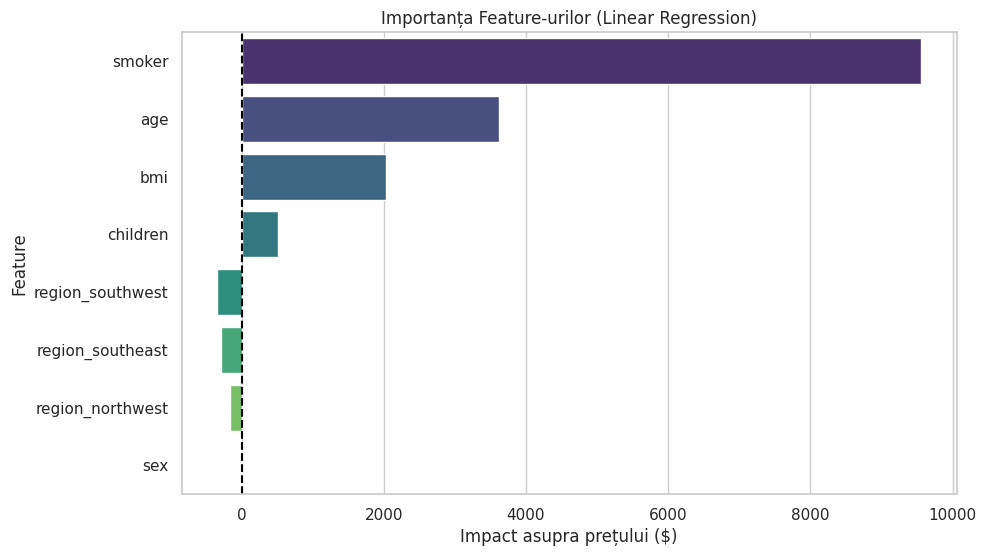

Interpretare: Observați cum 'smoker' domină complet graficul!


In [38]:
# Antrenăm modelul liniar simplu
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Extragem coeficienții
coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lin_reg.coef_
})

# Sortăm după valoarea absolută (magnitudine)
coefs['Abs_Coefficient'] = coefs['Coefficient'].abs()
coefs = coefs.sort_values(by='Abs_Coefficient', ascending=False)

# Vizualizare
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coefs, hue='Feature', palette='viridis')
plt.title('Importanța Feature-urilor (Linear Regression)')
plt.xlabel('Impact asupra prețului ($)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

print("Interpretare: Observați cum 'smoker' domină complet graficul!")

# 📈 2. Polynomial Regression (Prinderea curbelor)
Realitatea este rareori o linie dreaptă. De exemplu, costul medical ar putea crește exponențial cu vârsta, nu liniar.**Regresia Polinomială** creează variabile noi ridicând variabilele existente la putere sau înmulțindu-le între ele (ex: $Age^2$, $BMI \cdot Smoker$).

Vom folosi PolynomialFeatures din sklearn.

In [39]:
# 1. Creare Features Polinomiale (Gradul 2)
poly = PolynomialFeatures(degree=2, include_bias=False)

In [40]:
poly

PolynomialFeatures(include_bias=False)

In [41]:
# Transformăm X-ul original
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

print(f"Features originale: {X_train_scaled.shape[1]}")
print(f"Features polinomiale: {X_train_poly.shape[1]}")
# (Au crescut mult numărul de coloane!)

Features originale: 8
Features polinomiale: 44


In [42]:
# 2. Antrenare Model pe noile date
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

LinearRegression()

In [43]:
# 3. Evaluare
y_pred_poly = poly_reg.predict(X_val_poly)
r2_poly = r2_score(y_val, y_pred_poly)

print(f"\n📊 Performanță (R2 Score):")
print(f"Linear Simple: {r2_score(y_val, lin_reg.predict(X_val_scaled)):.4f}")
print(f"Polynomial (Deg 2): {r2_poly:.4f}")

if r2_poly > 0.8:
    print("✅ Modelul Polinomial este mult mai precis!")


📊 Performanță (R2 Score):
Linear Simple: 0.7836
Polynomial (Deg 2): 0.8666
✅ Modelul Polinomial este mult mai precis!


# 🔍 3. Feature Importance în Modelul Polinomial

Acum devine interesant. Care combinație de factori este cea mai periculoasă (scumpă)? Este doar fumatul, sau combinația **Fumat + Obezitate**?

In [44]:
len(poly_feature_names)

NameError: name 'poly_feature_names' is not defined

In [ ]:
# Obținem numele noilor coloane generate de PolynomialFeatures
poly_feature_names = poly.get_feature_names_out(feature_names)

# Creăm DataFrame cu coeficienți
poly_coefs = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': poly_reg.coef_
})

# Calculăm magnitudinea absolută
poly_coefs['Abs_Coefficient'] = poly_coefs['Coefficient'].abs()

# Afișăm doar TOP 10 cele mai importante features
top_10_features = poly_coefs.sort_values(by='Abs_Coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_10_features, hue='Feature', palette='magma')
plt.title('Top 10 Feature-uri Critice (Polynomial Regression)')
plt.xlabel('Impact ($)')
plt.show()

# 🎮 4. Predicție Interactivă

Acum e rândul tău! Folosește sliderele de mai jos pentru a configura un pacient ipotetic și vezi cât ar costa asigurarea lui conform modelului nostru Polinomial (cel mai bun).

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# --- Funcția de calcul (Logica) ---
def calculate_prediction(b):
    """
    Această funcție este apelată DOAR când se apasă butonul.
    Argumentul 'b' este obligatoriu (reprezintă butonul apăsat), dar nu îl folosim.
    """
    # 1. Curățăm output-ul precedent (ca să nu se adune rezultatele unul sub altul)
    out_result.clear_output()

    with out_result: # Orice print() în acest bloc va merge în widget-ul de output

        # 2. Preluăm valorile CURENTE din widget-uri
        age = w_age.value
        bmi = w_bmi.value
        children = w_children.value
        sex = w_sex.value
        smoker = w_smoker.value
        region = w_region.value

        # 3. Pregătim DataFrame-ul (exact ca la antrenare)
        input_data = pd.DataFrame({
            'age': [age],
            'sex': [1 if sex == 'Female' else 0],
            'bmi': [bmi],
            'children': [children],
            'smoker': [1 if smoker == 'Yes' else 0],
            'region_northwest': [1 if region == 'northwest' else 0],
            'region_southeast': [1 if region == 'southeast' else 0],
            'region_southwest': [1 if region == 'southwest' else 0]
        })

        # Asigurăm ordinea coloanelor
        input_data = input_data[X.columns]

        # 4. Scalare + Polinom
        try:
            input_scaled = scaler.transform(input_data)
            input_poly = poly.transform(input_scaled)

            # 5. Predicție
            prediction = poly_reg.predict(input_poly)[0]

            # Afișare stilizată
            print(f"📋 Profil Pacient: {age} ani, BMI {bmi}, Fumător: {smoker}")
            print("-" * 40)
            print(f"💰 COST ESTIMAT: ${prediction:,.2f}")

        except Exception as e:
            print(f"Eroare la calcul: {e}")
            print("Verifică dacă ai rulat celulele de antrenare anterioare!")


# --- Definirea Widget-urilor (Intrări) ---
style = {'description_width': 'initial'}

w_age = widgets.IntSlider(value=30, min=18, max=100, step=1, description='Vârstă:', style=style)
w_bmi = widgets.FloatSlider(value=25.0, min=15.0, max=55.0, step=0.1, description='BMI:', style=style)
w_children = widgets.IntSlider(value=0, min=0, max=10, step=1, description='Copii:', style=style)
w_sex = widgets.Dropdown(options=['Male', 'Female'], value='Male', description='Sex:', style=style)
w_smoker = widgets.Dropdown(options=['No', 'Yes'], value='No', description='Fumător:', style=style)
w_region = widgets.Dropdown(options=['northeast', 'northwest', 'southeast', 'southwest'],
                            value='southeast', description='Regiune:', style=style)

# --- Butonul de Predicție ---
btn_predict = widgets.Button(
    description='Calculează Prețul',
    button_style='success', # 'success' îl face verde, 'info' albastru, 'danger' roșu
    icon='calculator',
    layout=widgets.Layout(width='50%', height='40px')
)

# Legăm funcția de buton
btn_predict.on_click(calculate_prediction)

# --- Widget-ul de Output (Ecranul unde apare rezultatul) ---
out_result = widgets.Output()

# --- Aranjarea în pagină (Layout) ---
# Intrări Stânga
left_box = widgets.VBox([w_age, w_bmi, w_children])
# Intrări Dreapta
right_box = widgets.VBox([w_sex, w_smoker, w_region])
# Gruparea intrărilor
inputs_ui = widgets.HBox([left_box, right_box])

# Asamblarea finală: Intrări -> Buton -> Rezultat
final_ui = widgets.VBox([
    inputs_ui,
    widgets.Box([btn_predict], layout=widgets.Layout(justify_content='center', margin='20px 0px 0px 0px')),
    out_result
])

display(final_ui)